In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PATH   = r"C:\Users\Mayank Joshi\Downloads\Marketing_Channel_Project\data"
OUTPUT_PATH = os.path.join(DATA_PATH, 'segmentation')
os.makedirs(OUTPUT_PATH, exist_ok=True)

master    = pd.read_csv(os.path.join(DATA_PATH, 'master_table.csv'))
activated = pd.read_csv(os.path.join(DATA_PATH, 'cac_ltv', 'activated_sellers_ltv.csv'))

master['won_date']           = pd.to_datetime(master['won_date'], errors='coerce')
master['first_contact_date'] = pd.to_datetime(master['first_contact_date'], errors='coerce')
activated['won_date']        = pd.to_datetime(activated['won_date'], errors='coerce')

print(f"Master table    : {master.shape[0]:,} rows")
print(f"Activated sellers: {len(activated):,} sellers")
print(f"Output folder   : {OUTPUT_PATH}")

Master table    : 8,000 rows
Activated sellers: 380 sellers
Output folder   : C:\Users\Mayank Joshi\Downloads\Marketing_Channel_Project\data\segmentation


In [2]:
# Reference date — one day after the last won_date in the data
reference_date = activated['won_date'].max() + pd.Timedelta(days=1)

rfm = activated.copy()

# Recency — days since they won/joined (lower = more recent = better)
rfm['recency'] = (reference_date - rfm['won_date']).dt.days

# Frequency — total number of orders placed
rfm['frequency'] = rfm['total_orders']

# Monetary — total revenue generated
rfm['monetary'] = rfm['total_revenue']

rfm_table = rfm[['seller_id', 'origin', 'business_segment', 'lead_type',
                  'business_type', 'recency', 'frequency', 'monetary',
                  'avg_review_score', 'days_to_convert']].copy()

rfm_table['avg_review_score'] = rfm_table['avg_review_score'].fillna(
    rfm_table['avg_review_score'].median()
)
rfm_table['days_to_convert'] = rfm_table['days_to_convert'].fillna(
    rfm_table['days_to_convert'].median()
)

print("RFM TABLE SUMMARY")
print("=" * 45)
print(f"\n  Sellers          : {len(rfm_table):,}")
print(f"  Reference date   : {reference_date.date()}")
print(f"\n  Recency (days since joining):")
print(f"    Min : {rfm_table['recency'].min():.0f} days")
print(f"    Max : {rfm_table['recency'].max():.0f} days")
print(f"    Avg : {rfm_table['recency'].mean():.0f} days")
print(f"\n  Frequency (total orders):")
print(f"    Min : {rfm_table['frequency'].min():.0f}")
print(f"    Max : {rfm_table['frequency'].max():.0f}")
print(f"    Avg : {rfm_table['frequency'].mean():.1f}")
print(f"\n  Monetary (total revenue):")
print(f"    Min : ${rfm_table['monetary'].min():,.2f}")
print(f"    Max : ${rfm_table['monetary'].max():,.2f}")
print(f"    Avg : ${rfm_table['monetary'].mean():,.2f}")

RFM TABLE SUMMARY

  Sellers          : 380
  Reference date   : 2018-08-08

  Recency (days since joining):
    Min : 1 days
    Max : 239 days
    Avg : 127 days

  Frequency (total orders):
    Min : 1
    Max : 565
    Avg : 11.9

  Monetary (total revenue):
    Min : $18.90
    Max : $113,628.97
    Avg : $1,781.19


In [3]:
# Score each dimension 1-4 (4 = best)
rfm_table['R_score'] = pd.qcut(rfm_table['recency'],
                                q=4, labels=[4,3,2,1]).astype(int)
rfm_table['F_score'] = pd.qcut(rfm_table['frequency'].rank(method='first'),
                                q=4, labels=[1,2,3,4]).astype(int)
rfm_table['M_score'] = pd.qcut(rfm_table['monetary'].rank(method='first'),
                                q=4, labels=[1,2,3,4]).astype(int)

rfm_table['RFM_score'] = rfm_table['R_score'] + rfm_table['F_score'] + rfm_table['M_score']

def rfm_segment(score):
    if score >= 10:   return 'champions'
    elif score >= 8:  return 'loyal'
    elif score >= 6:  return 'promising'
    elif score >= 4:  return 'at_risk'
    else:             return 'dormant'

rfm_table['rfm_segment'] = rfm_table['RFM_score'].apply(rfm_segment)

seg_summary = (
    rfm_table.groupby('rfm_segment')
    .agg(
        sellers    = ('seller_id', 'count'),
        avg_revenue = ('monetary', 'mean'),
        avg_orders  = ('frequency', 'mean'),
        avg_recency = ('recency', 'mean')
    )
    .reset_index()
    .sort_values('avg_revenue', ascending=False)
)

print("RFM SEGMENTATION RESULTS")
print("=" * 65)
print(f"\n{'Segment':<15} {'Sellers':>8} {'Avg Revenue':>13} "
      f"{'Avg Orders':>12} {'Avg Recency':>13}")
print("-" * 65)
for _, row in seg_summary.iterrows():
    print(f"  {row['rfm_segment']:<13} {int(row['sellers']):>8} "
          f"${row['avg_revenue']:>11,.0f} {row['avg_orders']:>11.1f} "
          f"{row['avg_recency']:>11.0f} days")

rfm_table.to_csv(os.path.join(OUTPUT_PATH, 'rfm_scores.csv'), index=False)
print(f"\nrfm_scores.csv saved")

RFM SEGMENTATION RESULTS

Segment          Sellers   Avg Revenue   Avg Orders   Avg Recency
-----------------------------------------------------------------
  champions           73 $      3,852        29.0         101 days
  loyal              110 $      2,995        16.6         129 days
  promising          125 $        446         3.7         123 days
  at_risk             58 $        156         1.8         147 days
  dormant             14 $        100         1.0         185 days

rfm_scores.csv saved


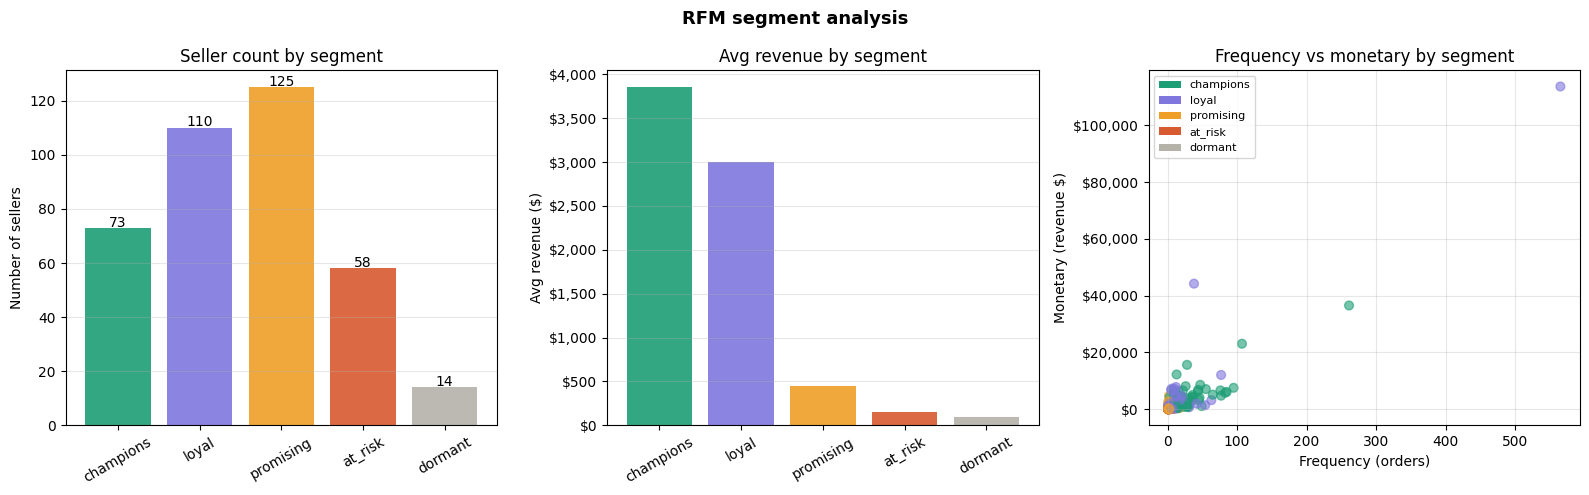

Chart saved


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM segment analysis', fontsize=13, fontweight='bold')

colors = {'champions':'#1D9E75', 'loyal':'#7F77DD',
          'promising':'#EF9F27', 'at_risk':'#D85A30', 'dormant':'#B4B2A9'}

seg_order = ['champions', 'loyal', 'promising', 'at_risk', 'dormant']
seg_colors = [colors[s] for s in seg_order]

counts = rfm_table['rfm_segment'].value_counts().reindex(seg_order)
axes[0].bar(seg_order, counts, color=seg_colors, alpha=0.9)
axes[0].set_title('Seller count by segment')
axes[0].set_ylabel('Number of sellers')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

rev_by_seg = rfm_table.groupby('rfm_segment')['monetary'].mean().reindex(seg_order)
axes[1].bar(seg_order, rev_by_seg, color=seg_colors, alpha=0.9)
axes[1].set_title('Avg revenue by segment')
axes[1].set_ylabel('Avg revenue ($)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].grid(axis='y', alpha=0.3)

axes[2].scatter(rfm_table['frequency'], rfm_table['monetary'],
                c=[colors.get(s, '#888780') for s in rfm_table['rfm_segment']],
                alpha=0.6, s=40)
axes[2].set_xlabel('Frequency (orders)')
axes[2].set_ylabel('Monetary (revenue $)')
axes[2].set_title('Frequency vs monetary by segment')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[s], label=s) for s in seg_order]
axes[2].legend(handles=legend_elements, fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'rfm_segments.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

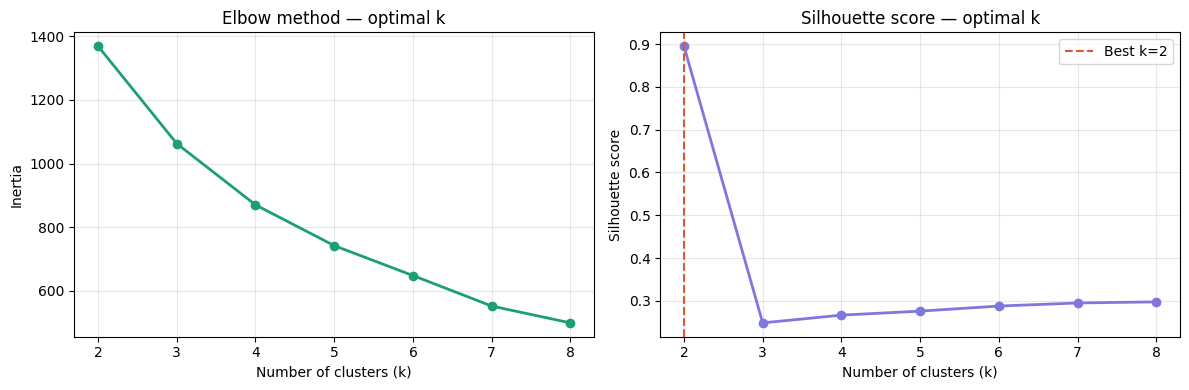

Optimal k by silhouette score: 2
Silhouette scores: [np.float64(0.895), np.float64(0.249), np.float64(0.267), np.float64(0.276), np.float64(0.288), np.float64(0.295), np.float64(0.298)]


In [5]:
# Features for clustering
features = ['recency', 'frequency', 'monetary', 'avg_review_score', 'days_to_convert']
X = rfm_table[features].copy()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal k using elbow method and silhouette score
inertias    = []
silhouettes = []
k_range     = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'o-', color='#1D9E75', linewidth=2)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method — optimal k')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouettes, 'o-', color='#7F77DD', linewidth=2)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score — optimal k')
axes[1].grid(alpha=0.3)

best_k = k_range[silhouettes.index(max(silhouettes))]
axes[1].axvline(x=best_k, color='#D85A30', linestyle='--',
                label=f'Best k={best_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'kmeans_optimal_k.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal k by silhouette score: {best_k}")
print(f"Silhouette scores: {[round(s,3) for s in silhouettes]}")

In [6]:
# The silhouette score picked k=2 because one outlier seller dominates
# mathematically. We override with k=4 for business-meaningful segments.
# First remove the extreme outlier before clustering

revenue_cap    = activated['total_revenue'].quantile(0.98)
rfm_no_outlier = rfm_table[rfm_table['monetary'] <= revenue_cap].copy()
rfm_outliers   = rfm_table[rfm_table['monetary'] > revenue_cap].copy()

print(f"Sellers in main clustering  : {len(rfm_no_outlier)}")
print(f"Outliers set aside          : {len(rfm_outliers)}")
print(f"Revenue cap (98th pctile)   : ${revenue_cap:,.0f}")

# Refit on cleaned data with k=4
X2        = rfm_no_outlier[features].copy()
X2_scaled = scaler.fit_transform(X2)

kmeans4   = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_no_outlier = rfm_no_outlier.copy()
rfm_no_outlier['cluster'] = kmeans4.fit_predict(X2_scaled)

# Label outliers as their own premium segment
rfm_outliers = rfm_outliers.copy()
rfm_outliers['cluster'] = 99

rfm_final = pd.concat([rfm_no_outlier, rfm_outliers], ignore_index=True)

cluster_summary2 = (
    rfm_final.groupby('cluster')
    .agg(
        sellers       = ('seller_id', 'count'),
        avg_revenue   = ('monetary', 'mean'),
        avg_orders    = ('frequency', 'mean'),
        avg_recency   = ('recency', 'mean'),
        total_revenue = ('monetary', 'sum')
    )
    .reset_index()
    .sort_values('avg_revenue', ascending=False)
)

cluster_summary2['revenue_share'] = (
    cluster_summary2['total_revenue'] /
    cluster_summary2['total_revenue'].sum() * 100
).round(1)

label_map = {}
sorted_c  = cluster_summary2.sort_values('avg_revenue', ascending=False)
names     = ['elite', 'high_value', 'mid_value', 'low_value', 'standard']
for i, (_, row) in enumerate(sorted_c.iterrows()):
    label_map[int(row['cluster'])] = names[i]

rfm_final['cluster_label'] = rfm_final['cluster'].map(label_map)

print(f"\nFINAL CLUSTER SUMMARY (k=4 + outlier segment)")
print("=" * 80)
print(f"\n{'Cluster':<8} {'Label':<15} {'Sellers':>8} {'Avg Revenue':>13} "
      f"{'Avg Orders':>12} {'Rev Share':>11}")
print("-" * 80)
for _, row in cluster_summary2.iterrows():
    label = label_map.get(int(row['cluster']), 'unknown')
    print(f"  {int(row['cluster']):<6} {label:<15} {int(row['sellers']):>8} "
          f"${row['avg_revenue']:>11,.0f} {row['avg_orders']:>11.1f} "
          f"{row['revenue_share']:>10.1f}%")

Sellers in main clustering  : 372
Outliers set aside          : 8
Revenue cap (98th pctile)   : $8,324

FINAL CLUSTER SUMMARY (k=4 + outlier segment)

Cluster  Label            Sellers   Avg Revenue   Avg Orders   Rev Share
--------------------------------------------------------------------------------
  99     elite                  8 $     33,251       142.0       39.3%
  3      high_value            34 $      5,224        37.9       26.2%
  2      mid_value            137 $        772         7.5       15.6%
  0      low_value             38 $        756         3.3        4.2%
  1      standard             163 $        605         5.8       14.6%


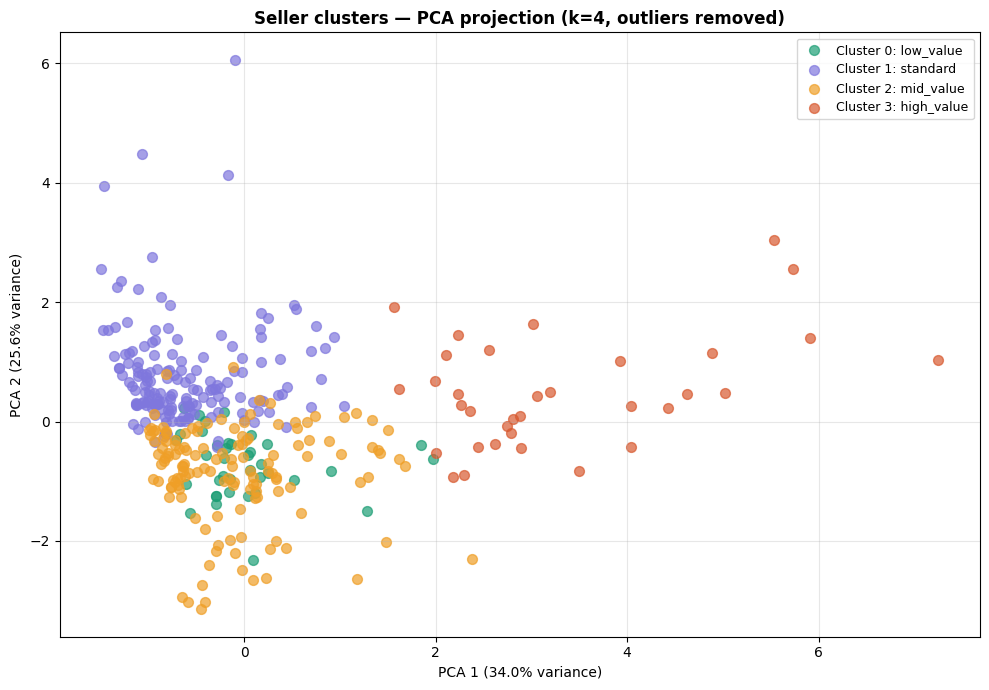

LOOKALIKE PROFILE — HIGH VALUE CLUSTER

  Cluster size    : 34 sellers
  Avg revenue     : $5,224
  Avg orders      : 37.9
  Avg review      : 4.14

  Top acquisition channels:
    paid_search                 11 sellers (32.4%)
    organic_search              10 sellers (29.4%)
    unknown                      6 sellers (17.6%)
    social                       2 sellers (5.9%)
    referral                     2 sellers (5.9%)
    direct_traffic               1 sellers (2.9%)
    other                        1 sellers (2.9%)
    email                        1 sellers (2.9%)

  Top business segments:
    household_utilities               7 sellers (20.6%)
    health_beauty                     5 sellers (14.7%)
    audio_video_electronics           3 sellers (8.8%)
    home_decor                        3 sellers (8.8%)
    sports_leisure                    2 sellers (5.9%)

  Business type:
    reseller               32 sellers (94.1%)
    manufacturer            2 sellers (5.9%)

  Lead 

In [7]:
# PCA on the non-outlier data
pca2    = PCA(n_components=2, random_state=42)
X2_pca  = pca2.fit_transform(X2_scaled)
rfm_no_outlier = rfm_no_outlier.copy()
rfm_no_outlier['pca_x'] = X2_pca[:, 0]
rfm_no_outlier['pca_y'] = X2_pca[:, 1]

cluster_colors2 = ['#1D9E75', '#7F77DD', '#EF9F27', '#D85A30']
fig, ax = plt.subplots(figsize=(10, 7))

for i, cluster_id in enumerate(sorted(rfm_no_outlier['cluster'].unique())):
    mask  = rfm_no_outlier['cluster'] == cluster_id
    label = label_map.get(cluster_id, str(cluster_id))
    ax.scatter(rfm_no_outlier.loc[mask, 'pca_x'],
               rfm_no_outlier.loc[mask, 'pca_y'],
               c=cluster_colors2[i % len(cluster_colors2)],
               label=f"Cluster {cluster_id}: {label}",
               alpha=0.7, s=50)

ax.set_xlabel(f'PCA 1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PCA 2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Seller clusters — PCA projection (k=4, outliers removed)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'kmeans_clusters_pca_final.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Lookalike profile on the high_value cluster
high_value_id      = [k for k,v in label_map.items() if v == 'high_value'][0]
top_cluster_final  = rfm_final[rfm_final['cluster'] == high_value_id]
rest_final         = rfm_final[rfm_final['cluster'] != high_value_id]

print("LOOKALIKE PROFILE — HIGH VALUE CLUSTER")
print("=" * 60)
print(f"\n  Cluster size    : {len(top_cluster_final)} sellers")
print(f"  Avg revenue     : ${top_cluster_final['monetary'].mean():,.0f}")
print(f"  Avg orders      : {top_cluster_final['frequency'].mean():.1f}")
print(f"  Avg review      : {top_cluster_final['avg_review_score'].mean():.2f}")

print(f"\n  Top acquisition channels:")
for ch, count in top_cluster_final['origin'].value_counts().items():
    pct = round(count/len(top_cluster_final)*100, 1)
    print(f"    {ch:<25} {count:>4} sellers ({pct}%)")

print(f"\n  Top business segments:")
for seg, count in top_cluster_final['business_segment'].value_counts().head(5).items():
    pct = round(count/len(top_cluster_final)*100, 1)
    print(f"    {seg:<30} {count:>4} sellers ({pct}%)")

print(f"\n  Business type:")
for bt, count in top_cluster_final['business_type'].value_counts().items():
    pct = round(count/len(top_cluster_final)*100, 1)
    print(f"    {bt:<20} {count:>4} sellers ({pct}%)")

print(f"\n  Lead type:")
for lt, count in top_cluster_final['lead_type'].value_counts().head(4).items():
    pct = round(count/len(top_cluster_final)*100, 1)
    print(f"    {lt:<25} {count:>4} sellers ({pct}%)")

rfm_final.to_csv(os.path.join(OUTPUT_PATH, 'sellers_segmented_final.csv'), index=False)
top_cluster_final.to_csv(os.path.join(OUTPUT_PATH, 'high_value_cluster_final.csv'), index=False)
print(f"\nFiles saved")

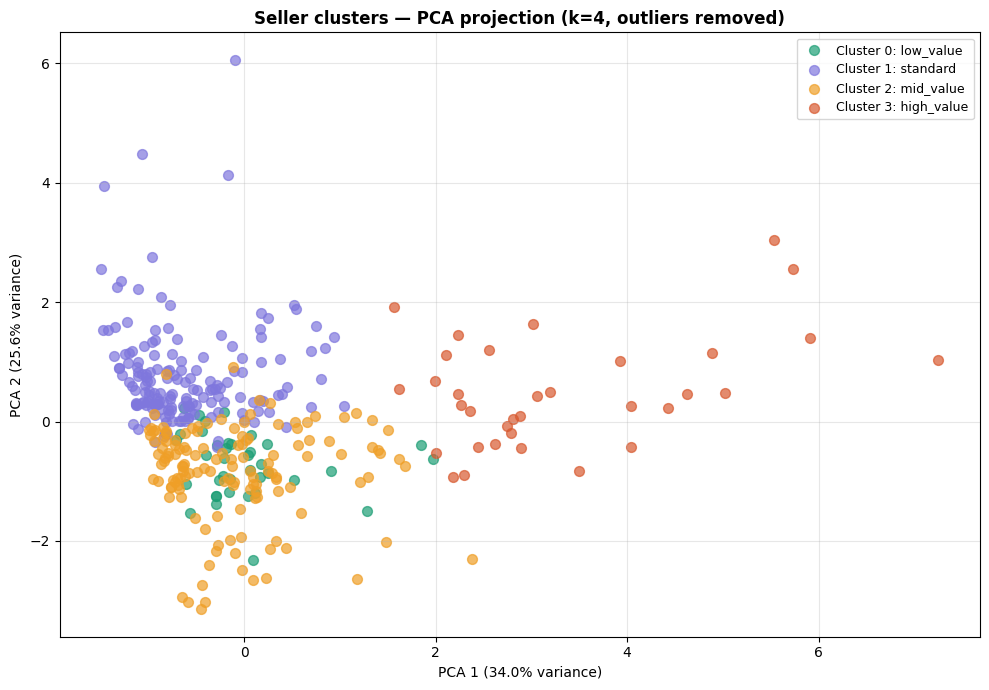

LOOKALIKE PROFILE — HIGH VALUE CLUSTER

  Cluster size    : 34 sellers
  Avg revenue     : $5,224
  Avg orders      : 37.9
  Avg review      : 4.14

  Top acquisition channels:
    paid_search                 11 sellers (32.4%)
    organic_search              10 sellers (29.4%)
    unknown                      6 sellers (17.6%)
    social                       2 sellers (5.9%)
    referral                     2 sellers (5.9%)
    direct_traffic               1 sellers (2.9%)
    other                        1 sellers (2.9%)
    email                        1 sellers (2.9%)

  Top business segments:
    household_utilities               7 sellers (20.6%)
    health_beauty                     5 sellers (14.7%)
    audio_video_electronics           3 sellers (8.8%)
    home_decor                        3 sellers (8.8%)
    sports_leisure                    2 sellers (5.9%)

  Business type:
    reseller               32 sellers (94.1%)
    manufacturer            2 sellers (5.9%)

  Lead 

In [8]:
# PCA on the non-outlier data
pca2    = PCA(n_components=2, random_state=42)
X2_pca  = pca2.fit_transform(X2_scaled)
rfm_no_outlier = rfm_no_outlier.copy()
rfm_no_outlier['pca_x'] = X2_pca[:, 0]
rfm_no_outlier['pca_y'] = X2_pca[:, 1]

cluster_colors2 = ['#1D9E75', '#7F77DD', '#EF9F27', '#D85A30']
fig, ax = plt.subplots(figsize=(10, 7))

for i, cluster_id in enumerate(sorted(rfm_no_outlier['cluster'].unique())):
    mask  = rfm_no_outlier['cluster'] == cluster_id
    label = label_map.get(cluster_id, str(cluster_id))
    ax.scatter(rfm_no_outlier.loc[mask, 'pca_x'],
               rfm_no_outlier.loc[mask, 'pca_y'],
               c=cluster_colors2[i % len(cluster_colors2)],
               label=f"Cluster {cluster_id}: {label}",
               alpha=0.7, s=50)

ax.set_xlabel(f'PCA 1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PCA 2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Seller clusters — PCA projection (k=4, outliers removed)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'kmeans_clusters_pca_final.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Lookalike profile on the high_value cluster
high_value_id      = [k for k,v in label_map.items() if v == 'high_value'][0]
top_cluster_final  = rfm_final[rfm_final['cluster'] == high_value_id]
rest_final         = rfm_final[rfm_final['cluster'] != high_value_id]

print("LOOKALIKE PROFILE — HIGH VALUE CLUSTER")
print("=" * 60)
print(f"\n  Cluster size    : {len(top_cluster_final)} sellers")
print(f"  Avg revenue     : ${top_cluster_final['monetary'].mean():,.0f}")
print(f"  Avg orders      : {top_cluster_final['frequency'].mean():.1f}")
print(f"  Avg review      : {top_cluster_final['avg_review_score'].mean():.2f}")

print(f"\n  Top acquisition channels:")
for ch, count in top_cluster_final['origin'].value_counts().items():
    pct = round(count/len(top_cluster_final)*100, 1)
    print(f"    {ch:<25} {count:>4} sellers ({pct}%)")

print(f"\n  Top business segments:")
for seg, count in top_cluster_final['business_segment'].value_counts().head(5).items():
    pct = round(count/len(top_cluster_final)*100, 1)
    print(f"    {seg:<30} {count:>4} sellers ({pct}%)")

print(f"\n  Business type:")
for bt, count in top_cluster_final['business_type'].value_counts().items():
    pct = round(count/len(top_cluster_final)*100, 1)
    print(f"    {bt:<20} {count:>4} sellers ({pct}%)")

print(f"\n  Lead type:")
for lt, count in top_cluster_final['lead_type'].value_counts().head(4).items():
    pct = round(count/len(top_cluster_final)*100, 1)
    print(f"    {lt:<25} {count:>4} sellers ({pct}%)")

rfm_final.to_csv(os.path.join(OUTPUT_PATH, 'sellers_segmented_final.csv'), index=False)
top_cluster_final.to_csv(os.path.join(OUTPUT_PATH, 'high_value_cluster_final.csv'), index=False)
print(f"\nFiles saved")

In [9]:
print("STAGE 5 COMPLETE — SEGMENTATION SUMMARY")
print("=" * 55)

print(f"\n  RFM segments:")
for _, row in seg_summary.iterrows():
    print(f"    {row['rfm_segment']:<15} {int(row['sellers']):>4} sellers  "
          f"avg ${row['avg_revenue']:,.0f}")

print(f"\n  K-means clusters (k=4 + elite outlier tier):")
for _, row in cluster_summary2.iterrows():
    label = label_map.get(int(row['cluster']), 'unknown')
    print(f"    Cluster {int(row['cluster'])} ({label:<15}) "
          f"{int(row['sellers']):>4} sellers  "
          f"avg ${row['avg_revenue']:,.0f}  "
          f"{row['revenue_share']:.1f}% of revenue")

print(f"\n  High value cluster profile:")
print(f"    Size            : {len(top_cluster_final)} sellers")
print(f"    Top channel     : {top_cluster_final['origin'].value_counts().index[0]}")
print(f"    Top segment     : {top_cluster_final['business_segment'].value_counts().index[0]}")
print(f"    Avg revenue     : ${top_cluster_final['monetary'].mean():,.0f}")

print(f"\n  Outputs saved to: {OUTPUT_PATH}")
print(f"  Ready for Stage 6 — Dashboard")

STAGE 5 COMPLETE — SEGMENTATION SUMMARY

  RFM segments:
    champions         73 sellers  avg $3,852
    loyal            110 sellers  avg $2,995
    promising        125 sellers  avg $446
    at_risk           58 sellers  avg $156
    dormant           14 sellers  avg $100

  K-means clusters (k=4 + elite outlier tier):
    Cluster 99 (elite          )    8 sellers  avg $33,251  39.3% of revenue
    Cluster 3 (high_value     )   34 sellers  avg $5,224  26.2% of revenue
    Cluster 2 (mid_value      )  137 sellers  avg $772  15.6% of revenue
    Cluster 0 (low_value      )   38 sellers  avg $756  4.2% of revenue
    Cluster 1 (standard       )  163 sellers  avg $605  14.6% of revenue

  High value cluster profile:
    Size            : 34 sellers
    Top channel     : paid_search
    Top segment     : household_utilities
    Avg revenue     : $5,224

  Outputs saved to: C:\Users\Mayank Joshi\Downloads\Marketing_Channel_Project\data\segmentation
  Ready for Stage 6 — Dashboard
